###################################
# Group ID : 420
# Members : Matias Mose,  Henrik Paaske Lind, Amalie Koch Andersen, Phillip Kaasgaard Sperling
# Date : 24-03-2025
# Lecture: Lecture 8 & 9: Linear Discriminant & Support Vector Machines
# Dependencies: None
# Python version: 3.12
# Functionality: This code loads the mnist_all.mat file and extracts the training data and assigns the correpsonding labels. A Linear Discriminant Analysis  and Principal Component Analysis are performed to reduce to 9 dimensions and compare performance. The data is split into training and testing, and used as input features for a Support Vector Machine. Finally, the two model are evaluated using a confusion matrix and a classificaiton report, outlining the models shortcomings and strenghts.
# .
# ###################################

### Imports

In [30]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.io import loadmat
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.decomposition import PCA


### **Exercise 1:** Perform classification for the entire dataset based on the algorithms introduced: Using LDA for dimensionality reduction (to 2 or 9 dimensions; LDA code "LDA.m" under the folder "Data and code" above) and compare PCA with LDA.

### Load data

In [31]:
data = loadmat("D:\PHD\Courses\Machine Learning\mnist_all.mat")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\SH37YE\AppData\Local\Temp\ipykernel_24944\2767627531.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = loadmat("D:\PHD\Courses\Machine Learning\mnist_all.mat")


### Extract data

In [32]:
train_0, train_1, train_2, train_3, train_4, train_5, train_6, train_7, train_8, train_9 = data['train0'] / 255, data[
    'train1'] / 255, data['train2'] / 255, data['train3'] / 255, data['train4'] / 255, data['train5'] / 255, data[
                                                                                               'train6'] / 255, data[
                                                                                               'train7'] / 255, data[
                                                                                               'train8'] / 255, data[
                                                                                               'train9'] / 255

### Assign labels

In [33]:
labels_0_train = np.full(train_0.shape[0], 0)
labels_1_train = np.full(train_1.shape[0], 1)
labels_2_train = np.full(train_2.shape[0], 2)
labels_3_train = np.full(train_3.shape[0], 3)
labels_4_train = np.full(train_4.shape[0], 4)
labels_5_train = np.full(train_5.shape[0], 5)
labels_6_train = np.full(train_6.shape[0], 6)
labels_7_train = np.full(train_7.shape[0], 7)
labels_8_train = np.full(train_8.shape[0], 8)
labels_9_train = np.full(train_9.shape[0], 9)

# Combine training sets
X_train = np.vstack((train_0, train_1, train_2, train_3, train_4,
                     train_5, train_6, train_7, train_8, train_9))  # Training data
y_train = np.hstack((labels_0_train, labels_1_train, labels_2_train, labels_3_train, labels_4_train,
                     labels_5_train, labels_6_train, labels_7_train, labels_8_train, labels_9_train))  # Training labels

print("training data input shape: " + str(np.shape(X_train)) + "\n" +
      "training data label shape: " + str(np.shape(y_train)) + "\n")

training data input shape: (60000, 784)
training data label shape: (60000,)



### Apply LDA (Reduce 784 → 9 (n classes - 1))

In [34]:

lda = LinearDiscriminantAnalysis(n_components=9)
X_train_lda = lda.fit_transform(X_train, y_train)

print("LDA data training data shape: " + str(np.shape(X_train_lda)))

LDA data training data shape: (60000, 9)


### Apply PCA for later comparison

In [35]:
pca = PCA(n_components=9)

X_train_pca = pca.fit_transform(X_train)

print("PCA data training data shape: " + str(np.shape(X_train_pca)))

PCA data training data shape: (60000, 9)


### Split data for faster learning --> 10% training data

In [36]:
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X_train_lda, y_train, test_size=0.1, random_state=42, stratify=y_train)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_train_pca, y_train, test_size=0.1, random_state=42, stratify=y_train)


### Use SVM for classification

In [37]:
svm_lda = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_lda.fit(X_train_lda, y_train_lda)

svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train_pca)

SVC(random_state=42)

### Predict on test data

In [38]:
y_pred_lda = svm_lda.predict(X_test_lda)

y_pred_pca = svm_pca.predict(X_test_pca)

### Evaluate performance

SVM Classification Accuracy: 0.9202
SVM Classification Accuracy: 0.9207


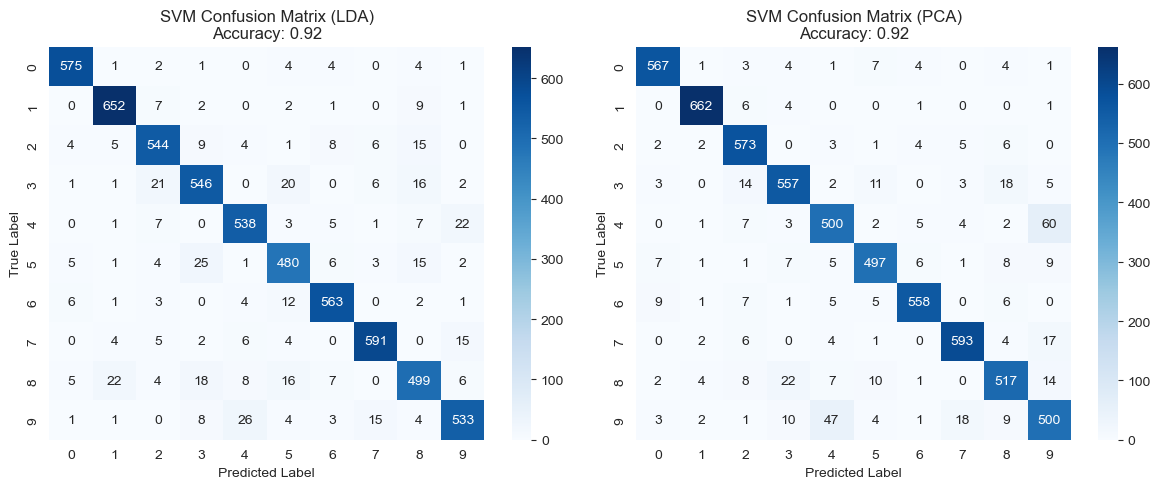


📋 Classification Report LDA:
              precision    recall  f1-score   support

     Class 0       0.96      0.97      0.97       592
     Class 1       0.95      0.97      0.96       674
     Class 2       0.91      0.91      0.91       596
     Class 3       0.89      0.89      0.89       613
     Class 4       0.92      0.92      0.92       584
     Class 5       0.88      0.89      0.88       542
     Class 6       0.94      0.95      0.95       592
     Class 7       0.95      0.94      0.95       627
     Class 8       0.87      0.85      0.86       585
     Class 9       0.91      0.90      0.90       595

    accuracy                           0.92      6000
   macro avg       0.92      0.92      0.92      6000
weighted avg       0.92      0.92      0.92      6000


 📋 Classification Report PCA:
              precision    recall  f1-score   support

     Class 0       0.96      0.96      0.96       592
     Class 1       0.98      0.98      0.98       674
     Class 2     

In [39]:
accuracy_lda = accuracy_score(y_test_lda, y_pred_lda)
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)
print(f"SVM Classification Accuracy: {accuracy_lda:.4f}")
print(f"SVM Classification Accuracy: {accuracy_pca:.4f}")

# Confusion Matrix
cm_lda = confusion_matrix(y_test_lda, y_pred_lda)
cm_pca = confusion_matrix(y_test_pca, y_pred_pca)


# Plot side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_lda, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10), ax=axes[0])
axes[0].set_title(f"SVM Confusion Matrix (LDA)\nAccuracy: {accuracy_lda:.2f}")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_pca, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10), ax=axes[1])
axes[1].set_title(f"SVM Confusion Matrix (PCA)\nAccuracy: {accuracy_pca:.2f}")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# Classification report
report_lda = classification_report(y_test_lda, y_pred_lda, target_names=[f"Class {i}" for i in range(10)])
report_pca = classification_report(y_test_pca, y_pred_pca, target_names=[f"Class {i}" for i in range(10)])
print("\n📋 Classification Report LDA:")
print(report_lda)

print("\n 📋 Classification Report PCA:")
print(report_pca)